In [24]:
# celula0

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

def instalar_se_necessario(pacote_import, pacote_pip=None):
    try:
        __import__(pacote_import)
        return False
    except ImportError:
        pacote_pip = pacote_pip or pacote_import
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote_pip])
        return True

instalados = []
if instalar_se_necessario("netCDF4"):
    instalados.append("netCDF4")
if instalar_se_necessario("cartopy"):
    instalados.append("cartopy")

import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

AMBIENTE_COLAB = "google.colab" in sys.modules

print("Célula 0 concluída.")
print(f"Ambiente Colab: {AMBIENTE_COLAB}")
print(f"Pacotes instalados nesta execução: {instalados if instalados else 'nenhum'}")

Célula 0 concluída.
Ambiente Colab: True
Pacotes instalados nesta execução: nenhum


In [25]:
# celula1

if AMBIENTE_COLAB:
    from google.colab import drive

MONTAR_GOOGLE_DRIVE = True
FORCAR_REMONTAGEM_DRIVE = False

def caminho_esta_montado(caminho):
    caminho = str(Path(caminho))
    try:
        texto_montagens = Path("/proc/mounts").read_text()
        return f" {caminho} " in texto_montagens or os.path.ismount(caminho)
    except Exception:
        return os.path.ismount(caminho)

def montar_drive_colab_seguro():
    caminho_drive = Path("/content/drive")
    caminho_mydrive = caminho_drive / "MyDrive"

    if not AMBIENTE_COLAB:
        return False

    if caminho_esta_montado(caminho_drive) and caminho_mydrive.exists():
        return True

    drive.mount(str(caminho_drive), force_remount=FORCAR_REMONTAGEM_DRIVE)

    if not caminho_mydrive.exists():
        raise RuntimeError("Google Drive não ficou acessível em /content/drive/MyDrive.")

    return True

if MONTAR_GOOGLE_DRIVE and AMBIENTE_COLAB:
    DRIVE_MONTADO = montar_drive_colab_seguro()
else:
    DRIVE_MONTADO = False

MYDRIVE = Path("/content/drive/MyDrive") if AMBIENTE_COLAB else Path.home()

# ======================================================================================
# CAMINHOS PRINCIPAIS
# ======================================================================================

RAIZ_DISSERTACAO = (
    MYDRIVE
    / "01_ESTUDOS"
    / "05_OCEANOGRAFIA"
    / "04_DISSERTACAO"
)

RAIZ_ARTIGO = (
    MYDRIVE
    / "01_ESTUDOS"
    / "06_MEUS_ARTIGOS"
    / "Artigo_TCC"
)

DIR_RODADAS = RAIZ_DISSERTACAO / "03_RODADAS"
DIR_OUTPUTS = RAIZ_DISSERTACAO / "06_OUTPUTS"

DIR_DADOS_DISSERTACAO = RAIZ_DISSERTACAO / "04_DADOS"
DIR_DADOS_ARTIGO = RAIZ_ARTIGO / "04_DADOS"

# ======================================================================================
# DADOS DE ESTAÇÕES
# ======================================================================================
# A figura usa as rodadas e outputs da dissertação, mas pode reaproveitar a base de estações
# do artigo, pois os domínios são os mesmos e a base INMET já está organizada lá.

CAMINHOS_DADOS_CANDIDATOS = [
    DIR_DADOS_DISSERTACAO,
    DIR_DADOS_ARTIGO,
]

def caminho_tem_base_estacoes(caminho_dados):
    caminho_dados = Path(caminho_dados)

    candidatos = [
        caminho_dados / "03_INMET" / "_BASE" / "estacoes_selecionadas_base.csv",
        caminho_dados / "03_INMET" / "_BASE" / "estacoes_base_comum_series_inmet.csv",
    ]

    if any(c.exists() for c in candidatos):
        return True

    padroes = [
        "*estac*.csv",
        "*estac*.xlsx",
        "*inmet*.csv",
        "*inmet*.xlsx",
        "*station*.csv",
        "*station*.xlsx",
    ]

    for padrao in padroes:
        try:
            if any(caminho_dados.rglob(padrao)):
                return True
        except Exception:
            pass

    return False

DIR_DADOS = None

for candidato in CAMINHOS_DADOS_CANDIDATOS:
    if candidato.exists() and caminho_tem_base_estacoes(candidato):
        DIR_DADOS = candidato
        break

if DIR_DADOS is None:
    for candidato in CAMINHOS_DADOS_CANDIDATOS:
        if candidato.exists():
            DIR_DADOS = candidato
            break

if DIR_DADOS is None:
    raise FileNotFoundError(
        "Nenhum diretório de dados foi encontrado. "
        f"Candidatos testados: {[str(c) for c in CAMINHOS_DADOS_CANDIDATOS]}"
    )

DIR_INMET_RAIZ = DIR_DADOS / "03_INMET"
DIR_INMET_BASE = DIR_INMET_RAIZ / "_BASE"
CAMINHO_ESTACOES_BASE = DIR_INMET_BASE / "estacoes_selecionadas_base.csv"

# aliases em minúsculo, compatíveis com o notebook antigo do artigo
dir_dados = DIR_DADOS
dir_inmet_raiz = DIR_INMET_RAIZ
dir_inmet_base = DIR_INMET_BASE
caminho_estacoes_base = CAMINHO_ESTACOES_BASE

# ======================================================================================
# SAÍDA FINAL
# ======================================================================================

DIR_AREA_ESTUDO = DIR_OUTPUTS / "area-estudo"
DIR_AREA_ESTUDO.mkdir(parents=True, exist_ok=True)

CAMINHO_FIGURA_FINAL = DIR_AREA_ESTUDO / "mapa_area_estudo.png"
CAMINHO_MAPA_AREA_ESTUDO = CAMINHO_FIGURA_FINAL

# ======================================================================================
# WRFOUT DE REFERÊNCIA
# ======================================================================================

RODADAS_PREFERENCIA = [
    "CTRL_NOV2022_dis",
    "CLIMSST_NOV2022_dis",
    "SSTN2008_NOV2022_dis",
    "CTRL_NOV2008_dis",
]

def procurar_wrfout_d01_referencia():
    for nome_rodada in RODADAS_PREFERENCIA:
        pasta = DIR_RODADAS / nome_rodada

        if pasta.exists():
            arquivos = sorted(pasta.glob("wrfout_d01_*"))
            if arquivos:
                return arquivos[0]

            arquivos = sorted(pasta.rglob("wrfout_d01_*"))
            if arquivos:
                return arquivos[0]

    arquivos_gerais = sorted(DIR_RODADAS.rglob("wrfout_d01_*"))

    if arquivos_gerais:
        return arquivos_gerais[0]

    raise FileNotFoundError(
        f"Nenhum arquivo wrfout_d01 foi encontrado em {DIR_RODADAS}"
    )

ARQUIVO_WRF_D01_REFERENCIA = procurar_wrfout_d01_referencia()

# ======================================================================================
# CHECAGENS
# ======================================================================================

if not DIR_RODADAS.exists():
    raise FileNotFoundError(f"Diretório de rodadas não encontrado: {DIR_RODADAS}")

if not DIR_OUTPUTS.exists():
    DIR_OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Célula 1 concluída.")
print(f"Drive montado: {DRIVE_MONTADO}")
print(f"Raiz da dissertação: {RAIZ_DISSERTACAO}")
print(f"Diretório de rodadas: {DIR_RODADAS}")
print(f"Diretório de outputs: {DIR_OUTPUTS}")
print(f"Diretório de dados usado para estações: {DIR_DADOS}")
print(f"INMET raiz: {DIR_INMET_RAIZ}")
print(f"Base de estações esperada: {CAMINHO_ESTACOES_BASE}")
print(f"Base de estações existe: {CAMINHO_ESTACOES_BASE.exists()}")
print(f"WRF d01 de referência: {ARQUIVO_WRF_D01_REFERENCIA}")
print(f"Figura final: {CAMINHO_FIGURA_FINAL}")

Célula 1 concluída.
Drive montado: True
Raiz da dissertação: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO
Diretório de rodadas: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/03_RODADAS
Diretório de outputs: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/06_OUTPUTS
Diretório de dados usado para estações: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/04_DADOS
INMET raiz: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/04_DADOS/03_INMET
Base de estações esperada: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/04_DADOS/03_INMET/_BASE/estacoes_selecionadas_base.csv
Base de estações existe: False
WRF d01 de referência: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/03_RODADAS/CTRL_NOV2022_dis/saida/wrfout_d01_2022-11-30_18:00:00
Figura final: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/06_OUTPUTS/area-estudo/mapa_area_estudo.png


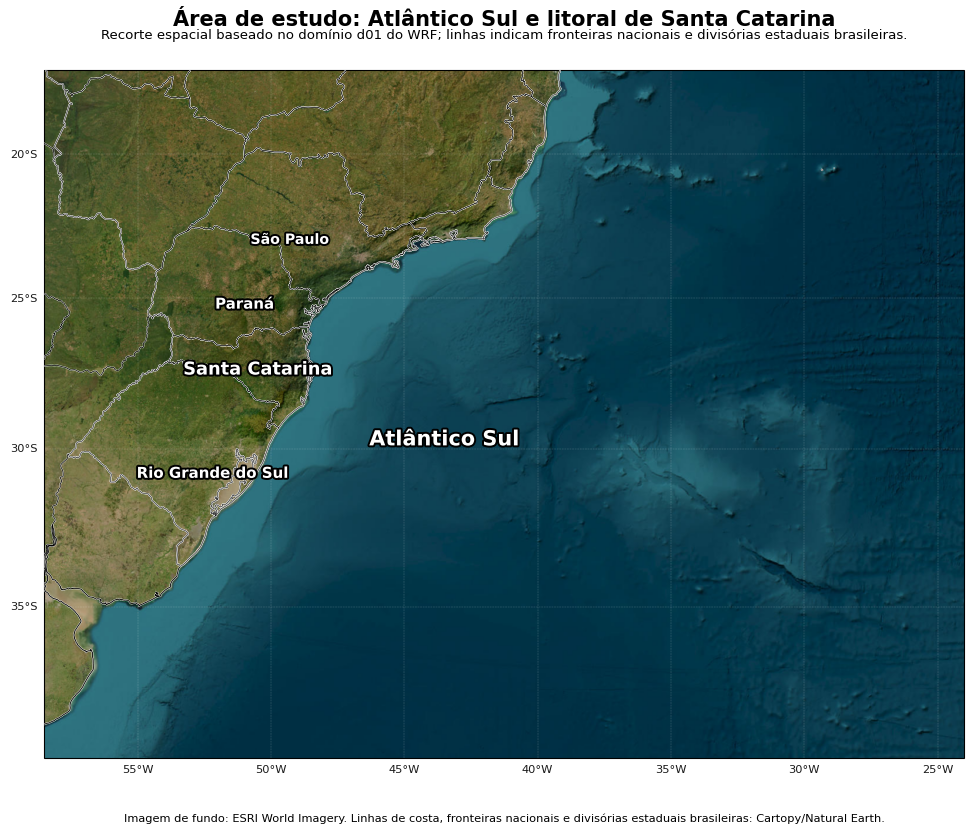

Arquivo d01 de referência: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/03_RODADAS/CTRL_NOV2022_dis/saida/wrfout_d01_2022-11-30_18:00:00
Fundo utilizado: ESRI World Imagery
Extent usado: [-58.5, -24.0, -39.5, -17.0]
Célula 2 concluída.
Figura salva em: /content/drive/MyDrive/01_ESTUDOS/05_OCEANOGRAFIA/04_DISSERTACAO/06_OUTPUTS/area-estudo/mapa_area_estudo.png


In [27]:
# celula2

FORCAR_REPLOTAGEM_MAPA_AREA_ESTUDO = True
TILES_ZOOM_AREA_ESTUDO = 6

import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# ======================================================================================
# TILE SATELITAL
# ======================================================================================

class EsriWorldImagery(cimgt.GoogleWTS):
    def _image_url(self, tile):
        x, y, z = tile
        return (
            "https://server.arcgisonline.com/ArcGIS/rest/services/"
            f"World_Imagery/MapServer/tile/{z}/{y}/{x}"
        )

# ======================================================================================
# LEITURA DA GRADE DO WRF
# ======================================================================================

def ler_grade_wrf(caminho_wrfout):
    with netCDF4.Dataset(str(caminho_wrfout)) as ds:
        if "XLAT" in ds.variables:
            lat = np.array(ds.variables["XLAT"][0], dtype=np.float32)
        else:
            lat = np.array(ds.variables["XLAT_M"][0], dtype=np.float32)

        if "XLONG" in ds.variables:
            lon = np.array(ds.variables["XLONG"][0], dtype=np.float32)
        else:
            lon = np.array(ds.variables["XLONG_M"][0], dtype=np.float32)

    lon = np.where(lon > 180.0, lon - 360.0, lon)
    return lat, lon

# ======================================================================================
# EXTENSÃO DO MAPA
# ======================================================================================

def obter_extent_area_estudo():
    lat_d01, lon_d01 = ler_grade_wrf(ARQUIVO_WRF_D01_REFERENCIA)

    lon_min = float(np.nanmin(lon_d01))
    lon_max = float(np.nanmax(lon_d01))
    lat_min = float(np.nanmin(lat_d01))
    lat_max = float(np.nanmax(lat_d01))

    # Mantém a lógica do d01, mas evita excesso continental a oeste.
    extent = [
        max(lon_min, -58.5),
        min(lon_max, -24.0),
        max(lat_min, -39.5),
        min(lat_max, -17.0),
    ]

    return extent

# ======================================================================================
# CAMADAS CARTOGRÁFICAS
# ======================================================================================

def configurar_grade(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.35,
        color="white",
        alpha=0.28,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True

    gl.xlabel_style = {"size": 8.2, "color": "0.1"}
    gl.ylabel_style = {"size": 8.2, "color": "0.1"}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-60, -20, 5))
    gl.ylocator = mticker.FixedLocator(np.arange(-40, -15, 5))

def adicionar_imagem_satelital(ax, tiler, extent):
    try:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_image(tiler, TILES_ZOOM_AREA_ESTUDO, interpolation="bilinear")
        return "ESRI World Imagery"
    except Exception as erro:
        warnings.warn(f"Falha ao carregar imagem satelital web: {erro}. Usando fallback stock_img.")
        ax.stock_img()
        return "Cartopy stock_img"

def adicionar_costa_fronteiras_paises(ax):
    # Costa com halo claro + linha escura
    ax.add_feature(
        cfeature.COASTLINE.with_scale("10m"),
        linewidth=1.25,
        edgecolor="white",
        alpha=0.85,
        zorder=6,
    )
    ax.add_feature(
        cfeature.COASTLINE.with_scale("10m"),
        linewidth=0.65,
        edgecolor="black",
        alpha=0.95,
        zorder=7,
    )

    # Fronteiras nacionais com halo claro + linha escura
    ax.add_feature(
        cfeature.BORDERS.with_scale("10m"),
        linewidth=1.15,
        edgecolor="white",
        alpha=0.80,
        zorder=6,
    )
    ax.add_feature(
        cfeature.BORDERS.with_scale("10m"),
        linewidth=0.55,
        edgecolor="black",
        alpha=0.95,
        zorder=7,
    )

def obter_geometrias_estados_brasil():
    shp = shpreader.natural_earth(
        resolution="10m",
        category="cultural",
        name="admin_1_states_provinces",
    )

    reader = shpreader.Reader(shp)
    geometrias = []

    for rec in reader.records():
        attrs = rec.attributes

        campos_brasil = [
            str(attrs.get("admin", "")).lower(),
            str(attrs.get("geonunit", "")).lower(),
            str(attrs.get("sovereignt", "")).lower(),
            str(attrs.get("adm0_a3", "")).upper(),
            str(attrs.get("iso_a2", "")).upper(),
        ]

        eh_brasil = (
            "brazil" in campos_brasil
            or "BRA" in campos_brasil
            or "BR" in campos_brasil
        )

        if eh_brasil:
            geometrias.append(rec.geometry)

    return geometrias

def adicionar_divisorias_estaduais_brasil(ax):
    geometrias = obter_geometrias_estados_brasil()

    if not geometrias:
        warnings.warn("Nenhuma geometria estadual do Brasil foi encontrada no Natural Earth.")
        return

    # Desenha contorno dos polígonos estaduais.
    # Halo claro primeiro, traço escuro depois.
    ax.add_geometries(
        geometrias,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="white",
        linewidth=1.05,
        alpha=0.82,
        zorder=8,
    )

    ax.add_geometries(
        geometrias,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=0.38,
        alpha=0.90,
        zorder=9,
    )

def adicionar_rotulos(ax):
    efeito = [pe.withStroke(linewidth=2.8, foreground="black")]

    rotulos = [
        ("São Paulo", -49.3, -23.0, 10.2),
        ("Paraná", -51.0, -25.2, 10.8),
        ("Santa Catarina", -50.5, -27.4, 12.8),
        ("Rio Grande do Sul", -52.2, -30.8, 10.8),
        ("Atlântico Sul", -43.5, -29.7, 15.0),
    ]

    for texto, lon, lat, tamanho in rotulos:
        ax.text(
            lon,
            lat,
            texto,
            fontsize=tamanho,
            fontweight="bold",
            color="white",
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=10,
            path_effects=efeito,
        )

# ======================================================================================
# FIGURA
# ======================================================================================

def gerar_mapa_area_estudo():
    extent = obter_extent_area_estudo()
    tiler = EsriWorldImagery()

    # Margens fixas: evita sobreposição entre título, mapa, e nota inferior.
    fig = plt.figure(figsize=(13.6, 8.6), facecolor="white")

    ax = fig.add_axes(
        [0.055, 0.105, 0.89, 0.80],
        projection=tiler.crs,
    )

    fundo_usado = adicionar_imagem_satelital(ax, tiler, extent)
    configurar_grade(ax, extent)

    adicionar_costa_fronteiras_paises(ax)
    adicionar_divisorias_estaduais_brasil(ax)
    adicionar_rotulos(ax)

    fig.suptitle(
        "Área de estudo: Atlântico Sul e litoral de Santa Catarina",
        fontsize=15,
        fontweight="bold",
        y=0.975,
    )

    fig.text(
        0.5,
        0.945,
        "Recorte espacial baseado no domínio d01 do WRF; linhas indicam fronteiras nacionais e divisórias estaduais brasileiras.",
        ha="center",
        va="center",
        fontsize=9.6,
    )

    fig.text(
        0.5,
        0.035,
        f"Imagem de fundo: {fundo_usado}. Linhas de costa, fronteiras nacionais e divisórias estaduais brasileiras: Cartopy/Natural Earth.",
        ha="center",
        va="center",
        fontsize=8.2,
    )

    CAMINHO_FIGURA_FINAL.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        CAMINHO_FIGURA_FINAL,
        dpi=230,
        facecolor="white",
    )

    plt.show()
    plt.close(fig)

    print(f"Arquivo d01 de referência: {ARQUIVO_WRF_D01_REFERENCIA}")
    print(f"Fundo utilizado: {fundo_usado}")
    print(f"Extent usado: {extent}")

if CAMINHO_FIGURA_FINAL.exists() and not FORCAR_REPLOTAGEM_MAPA_AREA_ESTUDO:
    img = plt.imread(str(CAMINHO_FIGURA_FINAL))
    fig, ax = plt.subplots(figsize=(13, 8), layout="constrained")
    ax.imshow(img)
    ax.axis("off")
    plt.show()
else:
    gerar_mapa_area_estudo()

print("Célula 2 concluída.")
print(f"Figura salva em: {CAMINHO_FIGURA_FINAL}")